In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [3]:
import os

print(os.getcwd())

C:\Users\Shruti\notebooks


In [4]:
import os
os.listdir()

['.ipynb_checkpoints', 'model_evaluation_and_tuning.ipynb']

In [5]:
import os
os.chdir(r"C:\Users\Shruti\Desktop\EDA")
print(os.getcwd())

C:\Users\Shruti\Desktop\EDA


In [6]:
df = pd.read_csv("data/cleaned_dataset.csv")

df.head()

,Age,Gender,problem_description,psychological_category
0,60,Male,even small tasks feel like huge burden lately,Depression
1,60,Female,partner doesnt communicate anymore hurts,Relationship
2,42,Female,days struggle get bed,Depression
3,56,Male,feel empty even im surrounded people,Depression
4,30,Female,theres constant conflict inlaws,Relationship


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1042 entries, 0 to 1041
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     1042 non-null   int64
 1   Gender                  1042 non-null   str  
 2   problem_description     1042 non-null   str  
 3   psychological_category  1042 non-null   str  
dtypes: int64(1), str(3)
memory usage: 32.7 KB


In [8]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)

X_text = tfidf.fit_transform(df["problem_description"])

In [10]:
le_target = LabelEncoder()

y = le_target.fit_transform(df["psychological_category"])

In [11]:
from scipy.sparse import hstack

X = hstack([df[["Age", "Gender"]].values, X_text])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

In [14]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [15]:
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_log, average="weighted"))
print("F1-Score :", f1_score(y_test, y_pred_log, average="weighted"))

Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [16]:
print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_tree, average="weighted"))
print("F1-Score :", f1_score(y_test, y_pred_tree, average="weighted"))

Decision Tree
Accuracy : 0.9952153110047847
Precision: 0.9953560371517028
Recall   : 0.9952153110047847
F1-Score : 0.9951953817205285


In [18]:
import os
print(os.getcwd())

C:\Users\Shruti\Desktop\EDA


In [19]:
plt.savefig("images/confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

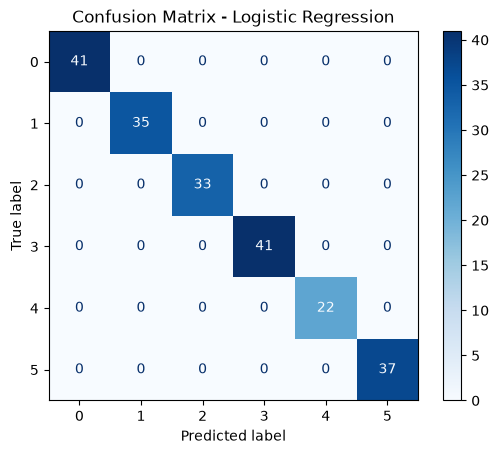

In [20]:
cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")

plt.savefig("images/confusion_matrix.png")

plt.show()

In [22]:
param_grid = {
    "C": [0.1, 1, 10],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 1.0


In [23]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_best, average="weighted"))
print("F1-Score :", f1_score(y_test, y_pred_best, average="weighted"))

Tuned Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [25]:
print("Decision Tree")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_dt, average="weighted"))
print("F1-Score :", f1_score(y_test, y_pred_dt, average="weighted"))

Decision Tree
Accuracy : 0.9952153110047847
Precision: 0.9953560371517028
Recall   : 0.9952153110047847
F1-Score : 0.9951953817205285


In [26]:
results = {
    "Tuned Logistic Regression": [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best, average="weighted"),
        recall_score(y_test, y_pred_best, average="weighted"),
        f1_score(y_test, y_pred_best, average="weighted")
    ],
    
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt, average="weighted"),
        recall_score(y_test, y_pred_dt, average="weighted"),
        f1_score(y_test, y_pred_dt, average="weighted")
    ]
}

import pandas as pd

comparison = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1-Score"]
)

comparison

,Tuned Logistic Regression,Decision Tree
Accuracy,1.0,0.995215
Precision,1.0,0.995356
Recall,1.0,0.995215
F1-Score,1.0,0.995195


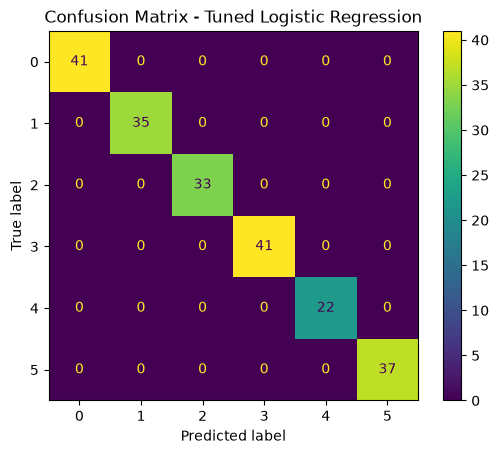

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Tuned Logistic Regression")

plt.savefig("logistic_confusion_matrix.png", bbox_inches="tight")

plt.show()

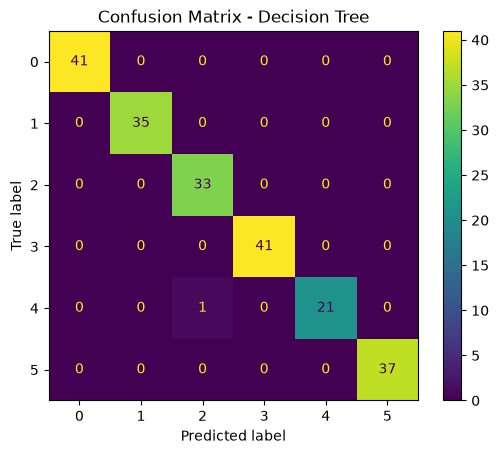

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()

plt.title("Confusion Matrix - Decision Tree")

plt.savefig("decision_tree_confusion_matrix.png", bbox_inches="tight")

plt.show()

In [29]:
import os
os.getcwd()

'C:\\Users\\Shruti\\Desktop\\EDA'